# Titanic Survival Prediction

## Project Overview

The Titanic dataset contains records of 891 passengers aboard 
the RMS Titanic, which sank in April 1912. The dataset includes 
features such as passenger class, gender, age, fare paid, and 
port of embarkation.

The goal of this project is to predict whether a passenger 
survived or not based on these features.

The workflow follows a standard ML pipeline:
- Exploratory Data Analysis (EDA)
- Data Cleaning and Handling Missing Values
- Data Visualization to identify patterns
- Feature Engineering
- Model Building — Logistic Regression and Random Forest
- Model Evaluation and Comparison

### Importing the required libraries and data

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

### Performing the EDA to check the data

In [2]:
print(data.head())
print(data.shape)
print(data.describe())

   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]
(891, 12)
       PassengerId    Survived      Pclass         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000    0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std     257.353842    0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min       1.000000    0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000    0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%     446.000000    0.000000    3.000000 

In [3]:
print(data.isnull().sum()) #checking for missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
print(data.dtypes) #checking the data types

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [5]:
print(data["Survived"].value_counts())
print(data["Survived"].mean()) #gives the survival rate

Survived
0    549
1    342
Name: count, dtype: int64
0.3838383838383838


### insights from EDA

- There is only 38% survival rate.
- 'Age' column has 177 missing values which is almost 20% of the data so it has to be filled with the appropriate value.
- 'Cabin' column has 687 null values which is almost 80% of the data so we can get rid of this entire column.
- 'Embarked' column has 2 null vales which can be eliminated.

For age column instead of filling the missing values with mean, it can be filled with the median age of the passengers classwise. For instance, the missing values of age where the pclass is first class we fill those values with the median value of the first class.

In [6]:
data = data.drop("Cabin",axis = 1) #dropping the column

data = data.dropna(subset = ["Embarked"]) #dropping nulls from the column "Embarked"

In [7]:
#filling the null age with the median values
data["Age"] = data["Age"].fillna(data.groupby("Pclass")["Age"].transform("median")) 

In [8]:
print(data.isnull().sum()) #verifiying the data cleaning part

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Visuals

### Importing the required libraries for visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

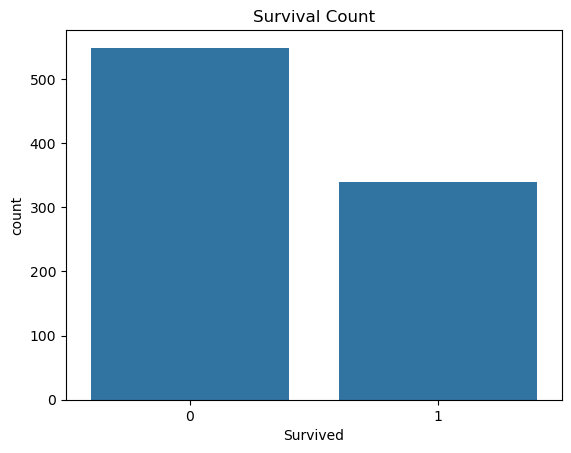

In [10]:
#survival count

sns.countplot(x = "Survived",data = data)
plt.title("Survival Count")
plt.show()

### Insights from the above graph
- Dataset is imbalanced — 62% died, 38% survived
- A model that predicts "everyone dies" would be 62% accurate
- This is why accuracy alone is not a reliable evaluation metric

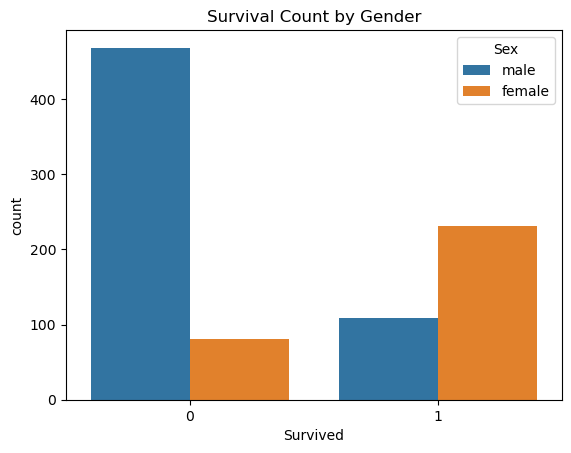

In [11]:
#survival count by gender

sns.countplot(x = "Survived",hue = "Sex",data = data)
plt.title("Survival Count by Gender")
plt.show() 

### Insight from the above graph
- Sex is the strongest predictor
- Females survived at dramatically higher rates than males

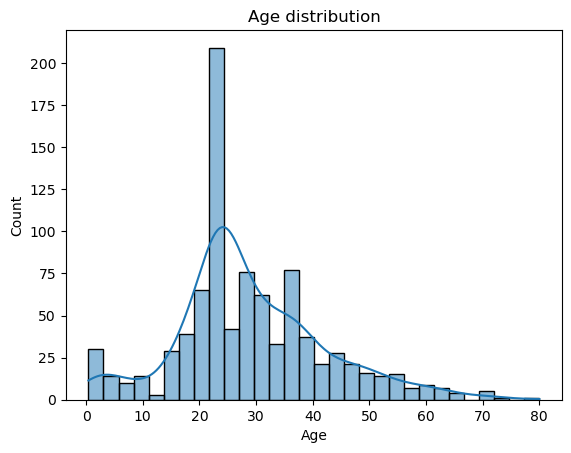

In [12]:
#Age distribution

sns.histplot(data["Age"],bins=30,kde=True)
plt.title("Age distribution")
plt.show()

### Insight from the above graph
- Most passengers were aged 20-40
- Very few above 60

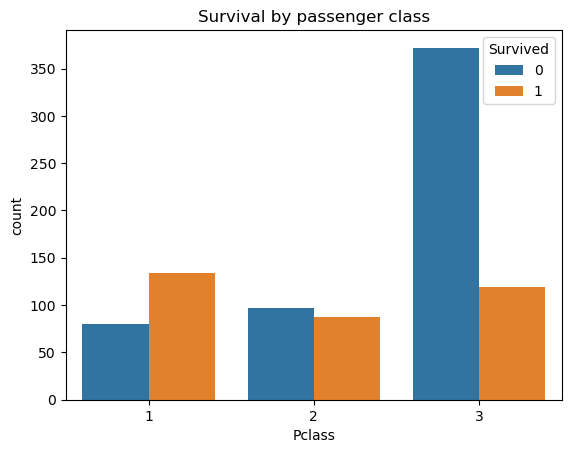

In [13]:
# Survival by Pclass

sns.countplot(x = "Pclass",hue = "Survived",data = data)
plt.title("Survival by passenger class")
plt.show()

### Insight from the above graph
- Pclass strongly predicts survival
- 1st class = highest survival, 3rd class = highest death
- Wealth and social class determined access to lifeboats

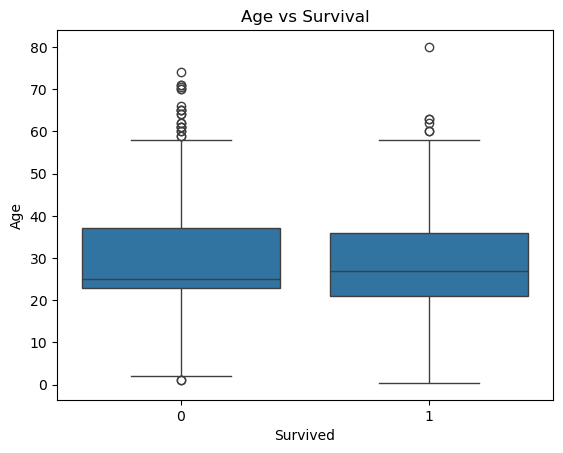

In [14]:
#Age vs Survival

sns.boxplot(x = "Survived",y = "Age",data = data)
plt.title("Age vs Survival")
plt.show()

### Insight from the above graph
- Age is a weak predictor alone
- Median age of survivors vs non-survivors is almost identical
- Weak separation between classes = low predictive power

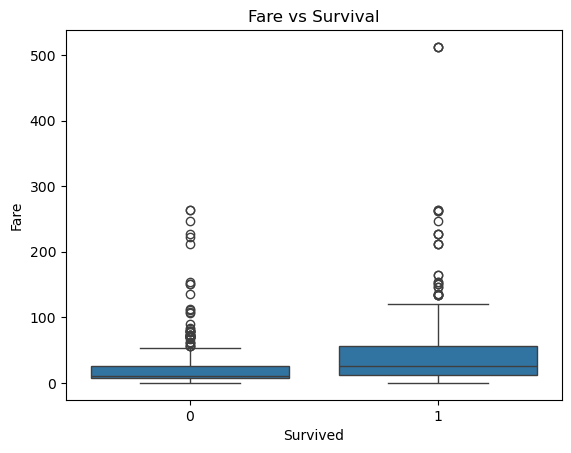

In [15]:
#Fare vs Survival

sns.boxplot(x = "Survived",y = "Fare",data = data)
plt.title("Fare vs Survival")
plt.show()

### Insights from the above graph
- Fare is a moderate predictor
- Survivors paid more than double the fare of non-survivors
- Fare correlates with Pclass — wealthier passengers survived more

# Feature Engineering

Using the insights from the visuals we now work on curating the features for our model.

### Label encoding
Converting the categorical data into numeric so that it is easy for us to work with the models as they are mathematical.

In [16]:
data["Sex"] = data["Sex"].map({"male" : 0,"female":1})
data["Embarked"] = data["Embarked"].map({"S" : 0,"C":1,"Q":2})

print(data[["Sex","Embarked"]].head())
print(data.dtypes)

   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked         int64
dtype: object


### Selecting features

In [17]:
features = ["Pclass","Age","Sex","Embarked","Fare"]
X = data[features] # independent variable
Y = data["Survived"] # dependent variable

print(X.shape)
print(Y.shape)

(889, 5)
(889,)


# modelling part

# 1. Logistic regression
Using logistic regression since our dependent variable is binary and we can get the probability of survival.

In [18]:
from sklearn.model_selection import train_test_split 

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)

(711, 5)
(178, 5)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [20]:
model = LogisticRegression()
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
Y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test,Y_pred))
print("Confusion matrix :\n", confusion_matrix(Y_test,Y_pred))

Accuracy : 0.7696629213483146
Confusion matrix :
 [[85 24]
 [17 52]]


## Logistic Regression Results

The Logistic Regression model achieved an accuracy of 77% on 
the unseen test data (20% split).

Confusion Matrix Breakdown:
- True Negatives  (Predicted Dead, Actually Dead)     : 85
- True Positives  (Predicted Survived, Actually Survived) : 52
- False Positives (Predicted Survived, Actually Dead)  : 24
- False Negatives (Predicted Dead, Actually Survived)  : 17

The model performed reasonably well as a baseline, correctly 
identifying 137 out of 178 passengers. However it struggled 
slightly more with identifying survivors, missing 17 actual 
survivors. This suggests room for improvement, which is 
addressed using Random Forest in the next section.

# 2. Random forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
rf_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test,rf_pred))
print("Confusion matrix :\n", confusion_matrix(Y_test,rf_pred))

Accuracy : 0.8258426966292135
Confusion matrix :
 [[92 17]
 [14 55]]


## Random Forest Results

The Random Forest model achieved an accuracy of 82.5% on 
the unseen test data (20% split).

Confusion Matrix Breakdown:
- True Negatives  (Predicted Dead, Actually Dead)        : 92
- True Positives  (Predicted Survived, Actually Survived): 55
- False Positives (Predicted Survived, Actually Dead)    : 17
- False Negatives (Predicted Dead, Actually Survived)    : 14

Random Forest outperformed Logistic Regression by 5.5%, 
correctly identifying 147 out of 178 passengers. It reduced 
both False Positives and False Negatives compared to the 
baseline model, showing improved prediction across both 
classes. This improvement is due to 100 decision trees 
voting collectively rather than a single model making 
predictions alone.

## Model Comparison and Conclusion

| Model               | Accuracy |
|---------------------|----------|
| Logistic Regression | 77.0%    |
| Random Forest       | 82.5%    |

Random Forest is the better performing model with 82.5% accuracy.
It outperformed Logistic Regression by 5.5% and showed improvement
in identifying survivors, reducing both False Positives and False
Negatives.

To improve further, feature engineering could be explored — such as
creating new features like Family Size (SibSp + Parch) or interaction
features between Age and Pclass to give the model more predictive power.

# Cross Validation

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model,X,Y,cv=5,scoring="accuracy")
print("RF Individual Fold scores :",scores)
print("RF Mean Accuracy :",scores.mean())
print("RF Standard Deviation :",scores.std())

Individual Fold scores : [0.78651685 0.80898876 0.85393258 0.79213483 0.83050847]
Mean Accuracy : 0.8144163016568271
Standard Deviation : 0.024999183517687186


## Results of Cross validation (Random Forest):
Cross Validation gives a more reliable accuracy estimate than single split. Mean CV Accuracy: 81.44% vs Single Split: 82.5%.
 Standard Deviation of 2.5% shows consistent performance across folds.
 CV score is slightly lower but more honest less dependent on random split.

In [25]:
scores_lr = cross_val_score(model,X,Y,cv=5,scoring="accuracy")
print("LR individual fold scores :",scores_lr)
print("LR mean accuracy :",scores_lr.mean())
print("LR standard deviation :",scores_lr.std())

LR individual fold scores : [0.7752809  0.79775281 0.79775281 0.7752809  0.79661017]
LR mean accuracy : 0.7885355170443724
LR standard deviation : 0.010830390198657258


## Results of Cross validation (Logistic Regression) :
Here in this case, the mean cross validation accuracy(78.8%) came out to be higher
than a single split accuracy(77%) with a standard deviation of only around 1%.
Meaning,single split happened to get a harder test set.
This makes it more reliable result compared to a single split.